# MegaPose-GSO: are one-scene keyframes geometrically sufficient?

This notebook audits the current **MegaPose-GSO-fixed** index and GSO mesh assets before changing the sampler. It answers two separate questions:

1. Can `N=2..8` references from one physical `(scene_id, gt_id)` track jointly describe enough of the object?
2. After requiring good reference coverage, how many cross-scene training/evaluation units remain under the calibrated-camera focal rule?

The source SQLite database remains read-only. Expensive derived visibility bitsets and track summaries go into a separate sidecar SQLite database.

## Important protocol distinctions

- `visib_fract` remains a per-frame quality gate; it is **not** treated as joint coverage.
- Surface coverage is estimated from a fixed 2,000-point GSO surface sample. A point counts only when its GT-pose projection agrees with both the released visible mask and metric depth, so external and self-occlusion are respected.
- Greedy marginal surface gain is the default anti-redundancy mechanism. A hard angular floor is optional, because nearby views can reveal different concavities or be occluded differently.
- Main validation keyframes are selected using reference data only. Requiring a reference within 10 degrees of a query uses query GT pose, so it belongs to supervised training or an explicitly labelled oracle diagnostic—not the primary deployment-style evaluation.
- A fixed 60% floor is not assumed. We first inspect coverage curves and sensitivity to the depth tolerance; an optional clean full-sphere render ceiling can normalize objects with intrinsically hard-to-observe surface regions.


## 0. Environment

Run from the repository root with the `pi3-lmgeo` kernel. The current training environment may not contain notebook/plotting packages; if needed, install them into that environment first:

```bash
conda activate pi3-lmgeo
python -m pip install jupyter ipykernel matplotlib
python -m ipykernel install --user --name pi3-lmgeo --display-name 'Pi3 LMGeo'
```

`pandas`, `numpy`, `scipy`, and Pillow are already used below. MegaPose, Panda3D, PyTorch3D, Open3D, and trimesh are not required.


In [1]:
from pathlib import Path
import hashlib
import io
import json
import math
import sqlite3
import sys

import numpy as np
import pandas as pd
from PIL import Image
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as error:
    raise ModuleNotFoundError('Install matplotlib in the selected notebook kernel; see cell 0.') from error

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'AGENTS.md').is_file():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / 'AGENTS.md').is_file():
    raise RuntimeError('Start Jupyter inside the Pi3 repository.')
sys.path.insert(0, str(REPO_ROOT))

from scripts.megapose_gso_keyframe_coverage import (
    greedy_coverage_curve,
    load_source_geometry,
    load_surface_pointcloud,
    max_pairwise_angle_degrees,
    minimum_enclosing_cap,
    object_view_direction,
    pack_surface_mask,
    read_indexed_payload,
    unpack_matrix,
    unpack_surface_mask,
    visible_surface_sample_mask,
)
from scripts.analyze_megapose_gso_focal_capacity import make_camera_profile

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)


In [2]:
# Paths and analysis policy. Change only this cell for another machine/run.
DATA_ROOT = Path('/media/internal/nvme/dtrofimov/datasets/MegaPose-GSO-fixed')
ASSETS_ROOT = Path('/media/internal/nvme/dtrofimov/datasets/MegaPose-GSO-assets')
INDEX_PATH = DATA_ROOT / 'pi3_index/megapose_gso.sqlite'
SPLIT_PATH = DATA_ROOT / 'pi3_index/megapose_gso.splits.json'
MODEL_CATALOG_PATH = ASSETS_ROOT / 'pi3_gso_models.json'
REFERENCE_INDEX_PATH = ASSETS_ROOT / 'renders/pi3_index/references.sqlite'
CACHE_PATH = DATA_ROOT / 'pi3_index/megapose_gso_keyframe_coverage.sqlite'

SPLIT = 'train'                 # repeat the final audit for 'val'
REFERENCE_VISIBILITY_MIN = 0.30
QUERY_VISIBILITY_MIN = 0.10
MIN_VISIBLE_PIXELS = 64
N_VALUES = tuple(range(2, 9))
FOCAL_LOG_TOLERANCE = 0.10
PRINCIPAL_POINT_TOLERANCE = 0.01
TARGET_RESOLUTION = (336, 252)  # width, height

# Start with a stratified pilot. A full scan means millions of depth/mask reads.
PILOT_OBJECT_COUNT = 12
PILOT_TRACKS_PER_OBJECT = 6
RUN_FULL_SPLIT = False           # set True only for a scheduled/resumable full scan
COMPUTE_SPHERICAL_CAP = True     # useful for pilot; disable to accelerate the full scan
RANDOM_SEED = 2026

# Validate these values with the sensitivity section before trusting coverage.
DEPTH_TOLERANCE_M = 0.002
DEPTH_TOLERANCE_RELATIVE = 0.002
PIXEL_RADIUS = 1
HARD_MIN_PAIRWISE_ANGLE_DEG = 0.0

for path in (INDEX_PATH, SPLIT_PATH, MODEL_CATALOG_PATH):
    if not path.is_file():
        raise FileNotFoundError(path)
print('Derived cache (source index is never modified):', CACHE_PATH)


Derived cache (source index is never modified): /media/internal/nvme/dtrofimov/datasets/MegaPose-GSO-fixed/pi3_index/megapose_gso_keyframe_coverage.sqlite


## 1. Open the source index read-only and inspect it with SQL/pandas

The source database contains poses, scalar visibility, boxes, intrinsics, depth units, and byte offsets. It does **not** contain surface-coverage labels. Keep arbitrary exploratory SQL in this section.


In [3]:
def open_readonly(path):
    uri = f'file:{Path(path).resolve()}?mode=ro&immutable=1'
    connection = sqlite3.connect(uri, uri=True)
    connection.row_factory = sqlite3.Row
    connection.execute('PRAGMA query_only = ON')
    return connection

source_db = open_readonly(INDEX_PATH)

def sql(query, params=()):
    return pd.read_sql_query(query, source_db, params=params)

metadata = sql('SELECT key, value FROM metadata ORDER BY key')
display(metadata)

population = sql('''
SELECT
  (SELECT COUNT(*) FROM frames) AS frames,
  (SELECT COUNT(*) FROM instances) AS observations,
  (SELECT COUNT(*) FROM scene_tracks) AS tracks,
  (SELECT COUNT(*) FROM scenes) AS scenes,
  (SELECT COUNT(*) FROM objects) AS objects
''')
display(population)


,key,value
0,data_root_at_preprocess_time,/media/internal/nvme/dtrofimov/datasets/MegaPo...
1,depth_unit_formula,raw_depth * depth_scale_raw * 0.001
2,expected_views_per_scene,40
3,index_complete,1
4,pose_convention,T_C_O maps object coordinates to camera coordi...
5,sampling_profiles_complete,1
6,schema_version,1
7,translation_unit,metre
8,updated_at_utc,2026-08-07T12:35:07+00:00


,frames,observations,tracks,scenes,objects
0,1000000,19997000,499925,25000,944


In [4]:
# Prepared entity split. Both target objects and source scenes are disjoint.
split_manifest = json.loads(SPLIT_PATH.read_text(encoding='utf-8'))
split_object_ids = set(map(int, split_manifest['splits'][SPLIT]['object_ids']))
split_scene_ids = set(map(int, split_manifest['splits'][SPLIT]['scene_ids']))
print(SPLIT, 'objects=', len(split_object_ids), 'scenes=', len(split_scene_ids))

tracks = sql('''
SELECT object_id, scene_id, gt_id, frame_count, visible_frame_count,
       clean_visible_frame_count, mean_visib_fract, max_visib_fract
FROM scene_tracks
''')
tracks = tracks[
    tracks.object_id.isin(split_object_ids) & tracks.scene_id.isin(split_scene_ids)
].copy()

multiplicity = (
    tracks.groupby(['object_id', 'scene_id']).size().rename('tracks_per_object_scene')
    .value_counts().sort_index().rename_axis('tracks_per_object_scene').to_frame('object_scene_pairs')
)
display(multiplicity)
print('Fraction with multiple physical tracks in one scene:',
      f"{(tracks.groupby(['object_id','scene_id']).size() > 1).mean():.3%}")

# The index only materializes visibility=0.1 profiles. The exact 0.3 gate is
# therefore evaluated from instance rows for selected tracks later.
display(sql('SELECT * FROM sampling_profiles ORDER BY visibility_min'))


train objects= 755 scenes= 20000


,object_scene_pairs
tracks_per_object_scene,
1,313556
2,3153
3,16
4,1


Fraction with multiple physical tracks in one scene: 1.001%


,profile_id,visibility_min,min_visible_pixels,depth_corruption_policy
0,default_all,0.1,64,all
1,default_clean_only,0.1,64,clean_only
2,default_exclude_known_bad,0.1,64,exclude_known_bad


### Interpretation checkpoint

The 40 frames are independently rendered views of one static scene, not temporal video frames. A physical target is `(scene_id, gt_id)`. `(scene_id, object_id)` is unsafe because the same object model can occur more than once.

Multiple tracks of the same object in one scene are rare, so combining same-scene tracks is a useful special case, not a general rescue strategy. If one-track coverage is poor, the realistic options are: explicitly accept partial maps, improve clean renders, or relax the one-scene restriction with a clearly labelled domain-shift cost.


## 2. Audit model/surface-sample coverage

`pi3_gso_models.json` is the missing bridge between SQLite `object_id` and geometry. The preferred coverage denominator is the vertex-only `models_pointcloud` OBJ: it contains 2,000 surface samples per object and has an explicit metric scale. Mesh vertex counts from the BOP PLY are not an area-uniform denominator.


In [5]:
catalog_payload = json.loads(MODEL_CATALOG_PATH.read_text(encoding='utf-8'))
models = pd.DataFrame(catalog_payload['objects'])
for column in ('pointcloud_obj', 'normalized_obj', 'bop_ply', 'texture'):
    models[column + '_exists'] = models[column].map(lambda value: (ASSETS_ROOT / value).is_file())
models['in_index'] = models.object_id.isin(set(sql('SELECT object_id FROM objects').object_id))
models['in_selected_split'] = models.object_id.isin(split_object_ids)
display(models[[
    'object_id', 'gso_id', 'diameter_m', 'vertex_count', 'split', 'in_index',
    'in_selected_split', 'pointcloud_obj_exists', 'normalized_obj_exists',
    'bop_ply_exists', 'texture_exists'
]].head())
display(models[[column for column in models if column.endswith('_exists')] + ['in_index']].sum())

# Cheap but explicit verification of the point-cloud denominator.
def obj_point_count(relative_path):
    with (ASSETS_ROOT / relative_path).open('r', encoding='utf-8') as stream:
        return sum(line.startswith('v ') for line in stream)

models['surface_point_count'] = models.pointcloud_obj.map(obj_point_count)
display(models.surface_point_count.value_counts().sort_index().to_frame('objects'))


,object_id,gso_id,diameter_m,vertex_count,split,in_index,in_selected_split,pointcloud_obj_exists,normalized_obj_exists,bop_ply_exists,texture_exists
0,0,ALPHABET_AZ_GRADIENT,0.237791,7346,train,True,True,True,True,True,True
1,1,Granimals_20_Wooden_ABC_Blocks_Wagon_g2TinmUGGHI,0.203597,6162,train,True,True,True,True,True,True
2,3,Perricone_MD_Health_Weight_Management_Supplements,0.302682,1138,train,True,True,True,True,True,True
3,4,Xyli_Pure_Xylitol,0.229856,2770,train,True,True,True,True,True,True
4,5,Melissa_Doug_Shape_Sorting_Clock,0.200036,3773,train,True,True,True,True,True,True


pointcloud_obj_exists    944
normalized_obj_exists    944
bop_ply_exists           944
texture_exists           944
in_index                 944
dtype: int64

,objects
surface_point_count,
2000,944


## 3. Select a reproducible, stratified pilot

Do not begin by scanning every frame. First sample objects across the track-count distribution and tracks across mean visibility. The pilot validates geometry thresholds and estimates whether the plan is obviously viable. The final claim still requires a full train/validation scan or a statistically justified confidence interval.


In [6]:
rng = np.random.default_rng(RANDOM_SEED)
object_population = (
    tracks.groupby('object_id').agg(
        track_count=('gt_id', 'size'),
        scene_count=('scene_id', 'nunique'),
        median_clean_views=('clean_visible_frame_count', 'median'),
    ).reset_index().sort_values('track_count')
)
quantile_positions = np.linspace(0, len(object_population) - 1, PILOT_OBJECT_COUNT).round().astype(int)
pilot_object_ids = object_population.iloc[quantile_positions].object_id.astype(int).tolist()

pilot_parts = []
for object_id in pilot_object_ids:
    candidates = tracks[tracks.object_id == object_id].sort_values(
        ['mean_visib_fract', 'scene_id', 'gt_id']
    )
    positions = np.linspace(0, len(candidates) - 1, min(PILOT_TRACKS_PER_OBJECT, len(candidates)))
    pilot_parts.append(candidates.iloc[np.unique(positions.round().astype(int))])
pilot_tracks = pd.concat(pilot_parts, ignore_index=True)
display(pilot_tracks.head(20))
print('Pilot objects:', pilot_tracks.object_id.nunique(), 'tracks:', len(pilot_tracks))


,object_id,scene_id,gt_id,frame_count,visible_frame_count,clean_visible_frame_count,mean_visib_fract,max_visib_fract
0,30,4095,5,40,0,0,0.000000,0.000000
1,30,12765,6,40,14,14,0.053386,0.619534
2,30,23225,10,40,17,17,0.193481,0.999351
3,30,15881,13,40,26,23,0.361003,1.000000
4,30,14856,12,40,39,31,0.610740,0.850497
5,30,13594,13,40,40,40,0.957835,1.000000
6,355,7934,13,40,0,0,0.000000,0.000000
7,355,6612,16,40,34,31,0.115175,0.335019
8,355,20413,13,40,38,38,0.242330,0.726544
9,355,16457,18,40,34,34,0.385511,0.899246


Pilot objects: 12 tracks: 72


## 4. Load eligible frame metadata for one physical track

This SQL query is the reusable workhorse. It applies the reference quality gate but still returns every field needed for direct depth/mask access. Adjust the query interactively to inspect objects, scenes, distances, projected sizes, or focal profiles.


In [7]:
TRACK_RECORDS_SQL = '''
SELECT i.frame_id, i.gt_id, i.scene_id, i.view_id, i.object_id,
       i.T_C_O_f32, i.visib_fract, i.px_count_all, i.px_count_visib,
       i.bbox_obj_x, i.bbox_obj_y, i.bbox_obj_w, i.bbox_obj_h,
       i.bbox_visib_x, i.bbox_visib_y, i.bbox_visib_w, i.bbox_visib_h,
       f.frame_key, f.width, f.height, f.depth_unit_m, f.K_f32,
       f.rgb_offset, f.rgb_size, f.depth_offset, f.depth_size,
       f.mask_visib_offset, f.mask_visib_size,
       s.relative_path
FROM instances AS i
JOIN frames AS f ON f.id=i.frame_id
JOIN shards AS s ON s.id=f.shard_id
WHERE i.object_id=? AND i.scene_id=? AND i.gt_id=?
  AND i.depth_corrupt=0 AND i.visib_fract>=? AND i.px_count_visib>=?
ORDER BY i.view_id
'''

def track_records(object_id, scene_id, gt_id, visibility_min=REFERENCE_VISIBILITY_MIN):
    return sql(TRACK_RECORDS_SQL, (
        int(object_id), int(scene_id), int(gt_id), float(visibility_min),
        int(MIN_VISIBLE_PIXELS),
    ))

example_key = None
example_records = None
for candidate in pilot_tracks.itertuples(index=False):
    candidate_records = track_records(candidate.object_id, candidate.scene_id, candidate.gt_id)
    if len(candidate_records) >= max(N_VALUES):
        example_key, example_records = candidate, candidate_records
        break
if example_records is None:
    raise RuntimeError('The pilot has no track with eight quality-gated frames; expand it.')
display(example_records[[
    'object_id', 'scene_id', 'gt_id', 'view_id', 'visib_fract',
    'px_count_visib', 'bbox_visib_w', 'bbox_visib_h'
]])
print('Eligible frames:', len(example_records))


,object_id,scene_id,gt_id,view_id,visib_fract,px_count_visib,bbox_visib_w,bbox_visib_h
0,30,23225,10,6,0.990062,7771,85,150
1,30,23225,10,8,0.416763,3590,53,98
2,30,23225,10,21,0.992788,5231,89,107
3,30,23225,10,24,0.989356,10410,98,164
4,30,23225,10,26,0.988923,5089,107,82
5,30,23225,10,28,0.999351,4621,104,50
6,30,23225,10,30,0.509225,3864,82,67
7,30,23225,10,38,0.936834,3871,98,65


Eligible frames: 8


## 5. Viewing-direction spread

For each pose, `u = normalize(-R.T @ t)`. We report maximum pairwise angle and an approximate minimum enclosing spherical-cap radius/solid angle. The cap is a compactness diagnostic, not a substitute for actual surface coverage.


max pairwise angle: 72.07096096796926
minimum cap: {'center': array([-0.19069918,  0.24329071,  0.95102232]), 'radius_degrees': 36.03548048427992, 'solid_angle_steradians': 1.202269585642274, 'solid_angle_fraction_of_sphere': 0.09567357374200636}


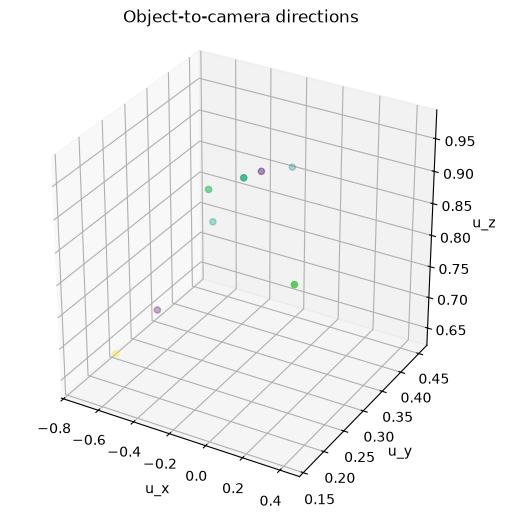

In [8]:
def directions_from_records(records):
    return np.stack([
        object_view_direction(unpack_matrix(value, 4, 4))
        for value in records.T_C_O_f32
    ])

example_directions = directions_from_records(example_records)
example_cap = minimum_enclosing_cap(example_directions)
print('max pairwise angle:', max_pairwise_angle_degrees(example_directions))
print('minimum cap:', example_cap)

fig = plt.figure(figsize=(7, 6))
axis = fig.add_subplot(111, projection='3d')
axis.scatter(*example_directions.T, c=example_records.view_id, cmap='viridis')
axis.set(xlabel='u_x', ylabel='u_y', zlabel='u_z', title='Object-to-camera directions')
axis.set_box_aspect((1, 1, 1))
plt.show()


## 6. Measure observed CAD-surface coverage

For every fixed CAD surface sample, this projects the sample with GT `T_C_O` and `K`, then requires agreement with a released visible-mask pixel and metric depth in a small neighborhood. Back-facing, self-occluded, externally occluded, off-image, and depth-inconsistent samples are rejected.

The depth tolerance is an estimator parameter, not ground truth. Run the sensitivity cell before fixing it. The renderer-convention validation in this repository found median depth disagreement around 0.03–0.14 mm on its checked samples, but pixel quantization and sparse surface samples motivate a larger starting tolerance here.


In [9]:
model_by_id = models.set_index('object_id').to_dict('index')
surface_cache = {}

def object_surface_points(object_id):
    object_id = int(object_id)
    if object_id not in surface_cache:
        model = model_by_id[object_id]
        surface_cache[object_id] = load_surface_pointcloud(
            ASSETS_ROOT / model['pointcloud_obj'], model['pointcloud_scale_m']
        )
    return surface_cache[object_id]

def frame_surface_mask(record, *, depth_tolerance_m=DEPTH_TOLERANCE_M):
    depth, visible_mask = load_source_geometry(DATA_ROOT, record)
    return visible_surface_sample_mask(
        object_surface_points(record['object_id']),
        unpack_matrix(record['T_C_O_f32'], 4, 4),
        unpack_matrix(record['K_f32'], 3, 3),
        depth, visible_mask,
        depth_tolerance_m=depth_tolerance_m,
        depth_tolerance_relative=DEPTH_TOLERANCE_RELATIVE,
        pixel_radius=PIXEL_RADIUS,
    )

example_masks = np.stack([frame_surface_mask(row) for row in example_records.to_dict('records')])
example_curve = greedy_coverage_curve(
    example_masks, example_directions, max(N_VALUES),
    minimum_pairwise_angle_degrees=HARD_MIN_PAIRWISE_ANGLE_DEG,
)
example_frame_coverage = example_masks.mean(axis=1)
display(pd.DataFrame({
    'view_id': example_records.view_id,
    'visib_fract': example_records.visib_fract,
    'surface_coverage': example_frame_coverage,
}).sort_values('surface_coverage', ascending=False))
display(pd.DataFrame({
    'N': np.arange(1, len(example_curve['coverage_fractions']) + 1),
    'union_surface_coverage': example_curve['coverage_fractions'],
    'marginal_surface_samples': example_curve['marginal_sample_gains'],
    'selected_view_id': example_records.iloc[example_curve['selected_indices']].view_id.to_numpy(),
}))
print('All eligible frames ceiling:', example_masks.any(axis=0).mean())


,view_id,visib_fract,surface_coverage
2,21,0.992788,0.5905
5,28,0.999351,0.5790
0,6,0.990062,0.5740
7,38,0.936834,0.5620
3,24,0.989356,0.5515
4,26,0.988923,0.5195
6,30,0.509225,0.3260
1,8,0.416763,0.2580


,N,union_surface_coverage,marginal_surface_samples,selected_view_id
0,1,0.5905,1181,21
1,2,0.6225,64,26
2,3,0.6325,20,28
3,4,0.6365,8,38
4,5,0.6380,3,30
5,6,0.6385,1,6
6,7,0.6385,0,8
7,8,0.6385,0,24


All eligible frames ceiling: 0.6385


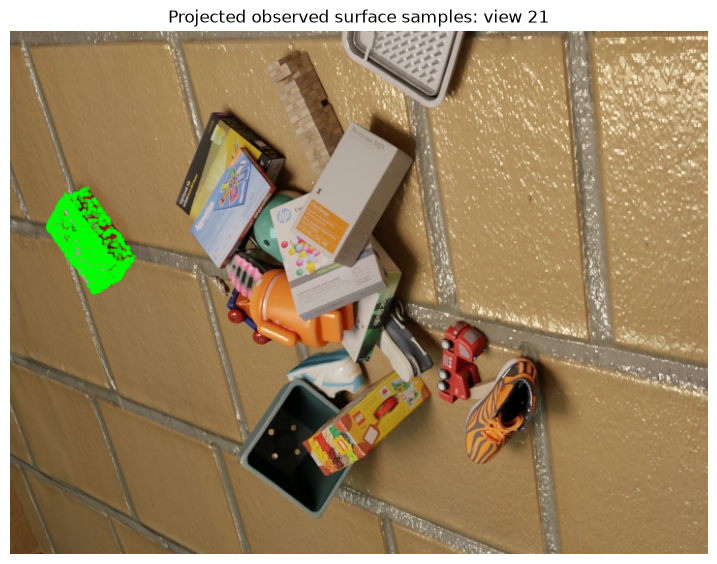

In [10]:
# Visual calibration: observed CAD samples should lie on the intended object.
preview_index = int(np.argmax(example_frame_coverage))
preview = example_records.iloc[preview_index].to_dict()
with Image.open(io.BytesIO(read_indexed_payload(DATA_ROOT, preview, 'rgb'))) as image:
    preview_rgb = np.asarray(image.convert('RGB')).copy()
points_O = object_surface_points(preview['object_id'])
T_C_O = unpack_matrix(preview['T_C_O_f32'], 4, 4)
K = unpack_matrix(preview['K_f32'], 3, 3)
points_C = points_O @ T_C_O[:3, :3].T + T_C_O[:3, 3]
projected = points_C @ K.T
uv = projected[:, :2] / projected[:, 2:3]
observed = example_masks[preview_index]
plt.figure(figsize=(9, 7))
plt.imshow(preview_rgb)
plt.scatter(uv[observed, 0], uv[observed, 1], s=5, c='lime', alpha=0.6)
plt.title(f"Projected observed surface samples: view {preview['view_id']}")
plt.axis('off')
plt.show()


,depth_tolerance_mm,median_frame_coverage,coverage_N5,all_frame_ceiling
0,0.5,0.54025,0.6315,0.6320
1,1.0,0.54550,0.6320,0.6325
2,2.0,0.55675,0.6380,0.6385
3,5.0,0.57900,0.6520,0.6530


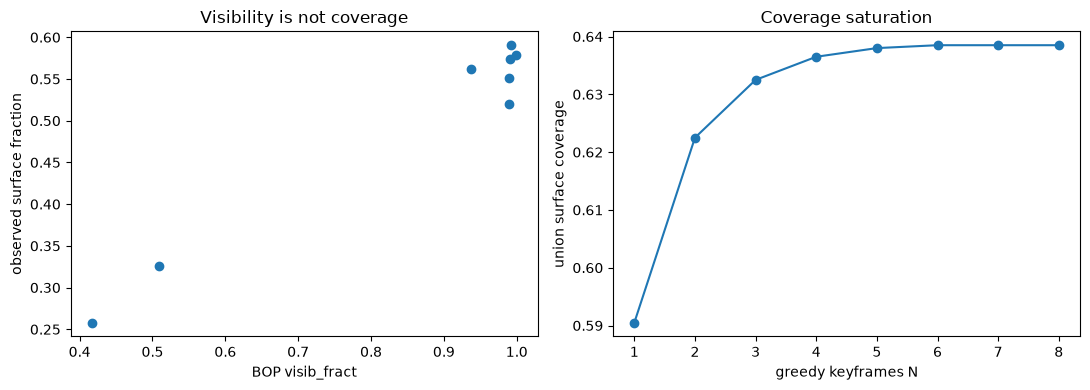

In [11]:
# Estimator sensitivity: conclusions should not depend strongly on one epsilon.
sensitivity = []
for tolerance_mm in (0.5, 1.0, 2.0, 5.0):
    masks = np.stack([
        frame_surface_mask(row, depth_tolerance_m=tolerance_mm / 1000.0)
        for row in example_records.to_dict('records')
    ])
    curve = greedy_coverage_curve(masks, example_directions, max(N_VALUES))
    sensitivity.append({
        'depth_tolerance_mm': tolerance_mm,
        'median_frame_coverage': float(np.median(masks.mean(axis=1))),
        'coverage_N5': curve['coverage_fractions'][4] if len(curve['coverage_fractions']) >= 5 else np.nan,
        'all_frame_ceiling': float(masks.any(axis=0).mean()),
    })
display(pd.DataFrame(sensitivity))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(example_records.visib_fract, example_frame_coverage)
axes[0].set(xlabel='BOP visib_fract', ylabel='observed surface fraction', title='Visibility is not coverage')
axes[1].plot(np.arange(1, len(example_curve['coverage_fractions']) + 1), example_curve['coverage_fractions'], marker='o')
axes[1].set(xlabel='greedy keyframes N', ylabel='union surface coverage', title='Coverage saturation', xticks=range(1, 9))
plt.tight_layout()
plt.show()


## 7. Cache pilot/full results in a sidecar SQLite database

Each frame stores a packed 2,000-bit visibility set (250 bytes) and each track stores the greedy prefixes. The `run_id` fingerprints estimator parameters and source files, so incompatible coverage estimates are never mixed. Delete the sidecar—not the source index—if you want to rebuild it.

The cell defaults to the pilot. For a complete audit, run this as a scheduled CPU/storage job over all split tracks after the tolerance pilot is stable. The notebook deliberately does not pretend a 72-track pilot is an exact global capacity count.


In [12]:
run_parameters = {
    'algorithm': 'gt_depth_visible_mask_surface_samples_v1',
    'split': SPLIT,
    'reference_visibility_min': REFERENCE_VISIBILITY_MIN,
    'min_visible_pixels': MIN_VISIBLE_PIXELS,
    'depth_tolerance_m': DEPTH_TOLERANCE_M,
    'depth_tolerance_relative': DEPTH_TOLERANCE_RELATIVE,
    'pixel_radius': PIXEL_RADIUS,
    'minimum_pairwise_angle_degrees': HARD_MIN_PAIRWISE_ANGLE_DEG,
    'compute_spherical_cap': COMPUTE_SPHERICAL_CAP,
    'index_mtime_ns': INDEX_PATH.stat().st_mtime_ns,
    'catalog_mtime_ns': MODEL_CATALOG_PATH.stat().st_mtime_ns,
}
RUN_ID = hashlib.sha256(json.dumps(run_parameters, sort_keys=True).encode()).hexdigest()[:16]
cache_db = sqlite3.connect(CACHE_PATH)
cache_db.executescript('''
CREATE TABLE IF NOT EXISTS analysis_runs (
    run_id TEXT PRIMARY KEY, parameters_json TEXT NOT NULL
);
CREATE TABLE IF NOT EXISTS frame_surface_visibility (
    run_id TEXT NOT NULL, object_id INTEGER NOT NULL, scene_id INTEGER NOT NULL,
    gt_id INTEGER NOT NULL, frame_id INTEGER NOT NULL, view_id INTEGER NOT NULL,
    visib_fract REAL NOT NULL, surface_point_count INTEGER NOT NULL,
    observed_point_count INTEGER NOT NULL, observed_bits BLOB NOT NULL,
    view_x REAL NOT NULL, view_y REAL NOT NULL, view_z REAL NOT NULL,
    PRIMARY KEY (run_id, frame_id, gt_id)
);
CREATE INDEX IF NOT EXISTS frame_surface_track
    ON frame_surface_visibility(run_id, object_id, scene_id, gt_id);
CREATE TABLE IF NOT EXISTS track_scan_status (
    run_id TEXT NOT NULL, object_id INTEGER NOT NULL, scene_id INTEGER NOT NULL,
    gt_id INTEGER NOT NULL, eligible_frame_count INTEGER NOT NULL, status TEXT NOT NULL,
    PRIMARY KEY (run_id, object_id, scene_id, gt_id)
);
CREATE TABLE IF NOT EXISTS track_surface_summary (
    run_id TEXT NOT NULL, object_id INTEGER NOT NULL, scene_id INTEGER NOT NULL,
    gt_id INTEGER NOT NULL, eligible_frame_count INTEGER NOT NULL,
    max_pairwise_angle_deg REAL NOT NULL, cap_radius_deg REAL NOT NULL,
    cap_solid_angle_sr REAL NOT NULL, all_frame_coverage REAL NOT NULL,
    coverage_curve_json TEXT NOT NULL, selected_view_ids_json TEXT NOT NULL,
    PRIMARY KEY (run_id, object_id, scene_id, gt_id)
);
''')
cache_db.execute(
    'INSERT OR REPLACE INTO analysis_runs VALUES (?, ?)',
    (RUN_ID, json.dumps(run_parameters, sort_keys=True)),
)
cache_db.commit()
print('RUN_ID:', RUN_ID)


RUN_ID: 017a74a2f3745f59


In [13]:
def analyze_and_cache_track(track):
    key = (int(track.object_id), int(track.scene_id), int(track.gt_id))
    records = track_records(*key)
    if len(records) < min(N_VALUES):
        cache_db.execute(
            'INSERT OR REPLACE INTO track_scan_status VALUES (?,?,?,?,?,?)',
            (RUN_ID, *key, len(records), 'insufficient_frames'),
        )
        cache_db.commit()
        return None
    directions = directions_from_records(records)
    masks = np.stack([frame_surface_mask(row) for row in records.to_dict('records')])
    curve = greedy_coverage_curve(
        masks, directions, max(N_VALUES),
        minimum_pairwise_angle_degrees=HARD_MIN_PAIRWISE_ANGLE_DEG,
    )
    cap = (minimum_enclosing_cap(directions) if COMPUTE_SPHERICAL_CAP else {
        'radius_degrees': np.nan, 'solid_angle_steradians': np.nan,
    })
    frame_rows = []
    for (_, row), direction, mask in zip(records.iterrows(), directions, masks):
        frame_rows.append((
            RUN_ID, *key, int(row.frame_id), int(row.view_id), float(row.visib_fract),
            len(mask), int(mask.sum()), pack_surface_mask(mask),
            float(direction[0]), float(direction[1]), float(direction[2]),
        ))
    cache_db.executemany(
        'INSERT OR REPLACE INTO frame_surface_visibility VALUES (?,?,?,?,?,?,?,?,?,?,?,?,?)',
        frame_rows,
    )
    selected_view_ids = records.iloc[curve['selected_indices']].view_id.astype(int).tolist()
    cache_db.execute(
        'INSERT OR REPLACE INTO track_surface_summary VALUES (?,?,?,?,?,?,?,?,?,?,?)',
        (RUN_ID, *key, len(records), max_pairwise_angle_degrees(directions),
         float(cap['radius_degrees']), float(cap['solid_angle_steradians']),
         float(masks.any(axis=0).mean()), json.dumps(curve['coverage_fractions']),
         json.dumps(selected_view_ids)),
    )
    cache_db.execute(
        'INSERT OR REPLACE INTO track_scan_status VALUES (?,?,?,?,?,?)',
        (RUN_ID, *key, len(records), 'complete'),
    )
    cache_db.commit()
    return key

# Exact reference eligibility is checked inside analyze_and_cache_track.
tracks_to_analyze = tracks if RUN_FULL_SPLIT else pilot_tracks

completed = []
for number, track in enumerate(tracks_to_analyze.itertuples(index=False), 1):
    result = analyze_and_cache_track(track)
    if result is not None:
        completed.append(result)
    if number % 10 == 0 or number == len(tracks_to_analyze):
        print(f'{number}/{len(tracks_to_analyze)} tracks visited; {len(completed)} cached')


10/72 tracks visited; 6 cached
20/72 tracks visited; 14 cached
30/72 tracks visited; 23 cached
40/72 tracks visited; 31 cached
50/72 tracks visited; 39 cached
60/72 tracks visited; 48 cached
70/72 tracks visited; 56 cached
72/72 tracks visited; 58 cached


## 8. The decision plots

The primary curve is the fraction of physical tracks reaching each coverage floor for each `N`. Also inspect the all-frame ceiling: if many tracks have low ceiling, no within-track selection method can fix them. Report distributions per object as well as pooled tracks so frequent objects do not dominate the conclusion.


cached summaries=58; scanned statuses=72/319,914; full=False


,run_id,object_id,scene_id,gt_id,eligible_frame_count,status,max_pairwise_angle_deg,cap_radius_deg,cap_solid_angle_sr,all_frame_coverage,coverage_curve_json,selected_view_ids_json,coverage_n1,coverage_n2,coverage_n3,coverage_n4,coverage_n5,coverage_n6,coverage_n7,coverage_n8
0,017a74a2f3745f59,30,4095,5,0,insufficient_frames,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,017a74a2f3745f59,30,12765,6,1,insufficient_frames,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,017a74a2f3745f59,30,13594,13,39,complete,168.628782,85.394427,5.778671,0.994,"[0.5895, 0.8545, 0.9795, 0.9855, 0.991, 0.993,...","[12, 33, 10, 28, 20, 1, 3, 4]",0.5895,0.8545,0.9795,0.9855,0.9910,0.993,0.9935,0.994
3,017a74a2f3745f59,30,14856,12,26,complete,143.651099,71.828351,4.323681,0.785,"[0.47, 0.642, 0.714, 0.7385, 0.7525, 0.764, 0....","[24, 34, 36, 18, 29, 13, 6, 39]",0.4700,0.6420,0.7140,0.7385,0.7525,0.764,0.7710,0.776
4,017a74a2f3745f59,30,15881,13,16,complete,162.031379,83.952975,5.621285,0.910,"[0.5845, 0.8195, 0.8965, 0.903, 0.9065, 0.91, ...","[24, 4, 36, 3, 0, 5, 2, 6]",0.5845,0.8195,0.8965,0.9030,0.9065,0.910,0.9100,0.910


,N,coverage_floor,track_fraction,mean_per_object_fraction,track_count,object_count
2,2,0.6,0.541667,0.541667,72,12
7,3,0.6,0.638889,0.638889,72,12
12,4,0.6,0.652778,0.652778,72,12
17,5,0.6,0.666667,0.666667,72,12
22,6,0.6,0.652778,0.652778,72,12
27,7,0.6,0.652778,0.652778,72,12
32,8,0.6,0.652778,0.652778,72,12


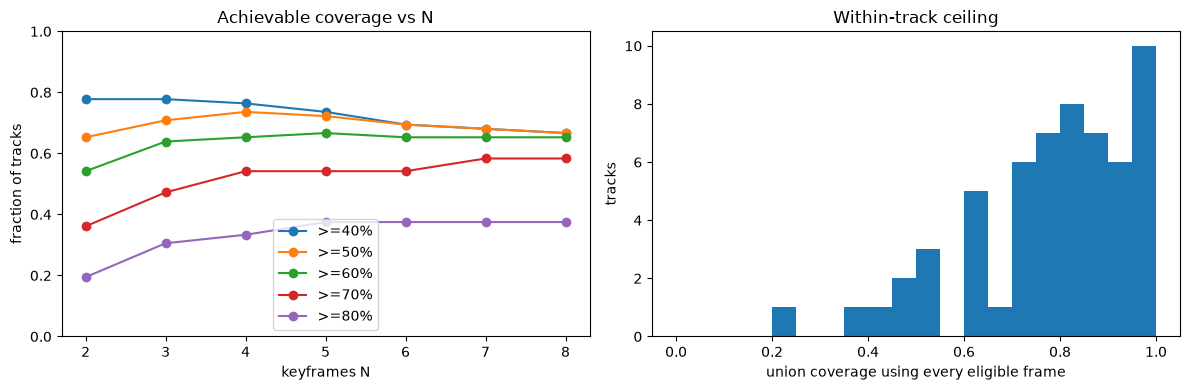

In [14]:
track_summary = pd.read_sql_query(
    'SELECT * FROM track_surface_summary WHERE run_id=?', cache_db, params=(RUN_ID,)
)
scan_status = pd.read_sql_query(
    'SELECT * FROM track_scan_status WHERE run_id=?', cache_db, params=(RUN_ID,)
)
scanned_track_count = len(scan_status)
CACHE_IS_FULL_SPLIT = scanned_track_count == len(tracks)
summary = scan_status.merge(
    track_summary.drop(columns=['eligible_frame_count']),
    on=['run_id', 'object_id', 'scene_id', 'gt_id'], how='left',
)
print(f'cached summaries={len(track_summary):,}; scanned statuses={scanned_track_count:,}/{len(tracks):,}; full={CACHE_IS_FULL_SPLIT}')
curves = summary.coverage_curve_json.map(
    lambda value: json.loads(value) if isinstance(value, str) else []
)
for n in range(1, max(N_VALUES) + 1):
    summary[f'coverage_n{n}'] = curves.map(lambda values: values[n-1] if len(values) >= n else np.nan)
display(summary.head())

floors = (0.40, 0.50, 0.60, 0.70, 0.80)
viability_rows = []
for n in N_VALUES:
    for floor in floors:
        # A track with fewer than N eligible frames is a failure for that N, not
        # something to remove from the denominator.
        values = summary[f'coverage_n{n}']
        # Equal-track and equal-object summaries answer different questions.
        track_fraction = float((values >= floor).mean()) if len(values) else np.nan
        per_object = summary.assign(pass_floor=summary[f'coverage_n{n}'] >= floor).groupby('object_id').pass_floor.mean()
        viability_rows.append({
            'N': n, 'coverage_floor': floor, 'track_fraction': track_fraction,
            'mean_per_object_fraction': float(per_object.mean()) if len(per_object) else np.nan,
            'track_count': len(values), 'object_count': summary.object_id.nunique(),
        })
viability = pd.DataFrame(viability_rows)
display(viability[viability.coverage_floor == 0.60])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for floor, values in viability.groupby('coverage_floor'):
    axes[0].plot(values.N, values.track_fraction, marker='o', label=f'>={floor:.0%}')
axes[0].set(xlabel='keyframes N', ylabel='fraction of tracks', ylim=(0, 1), title='Achievable coverage vs N')
axes[0].legend()
axes[1].hist(summary.all_frame_coverage, bins=np.linspace(0, 1, 21))
axes[1].set(xlabel='union coverage using every eligible frame', ylabel='tracks', title='Within-track ceiling')
plt.tight_layout()
plt.show()


## 9. Optional observable-surface normalization with clean full-sphere renders

Absolute coverage is the main interpretable number. However, some mesh samples may be effectively unobservable because of deep concavities, bottoms, or model artifacts. The clean reference bank has 512 full-sphere views per object and can define an object-specific observable universe.

For a pilot object, load each reference `depth_relpath` and `mask_visib_relpath`, project the same surface samples with the indexed `T_C_O`/`K`, and union the results. Then report both:

- `absolute_coverage = selected_union / 2000`;
- `observable_normalized_coverage = selected_union intersect render_universe / render_universe`.

Do not silently replace the absolute number. If conclusions change strongly after normalization, inspect the mesh and the render-universe estimator. The next cell computes the universe for the example object from ordinary reference PNG paths.


In [15]:
if REFERENCE_INDEX_PATH.is_file():
    reference_db = open_readonly(REFERENCE_INDEX_PATH)
    reference_rows = pd.read_sql_query(
        'SELECT * FROM views WHERE object_id=? ORDER BY coverage_view_id',
        reference_db, params=(int(example_key.object_id),),
    )
    display(reference_rows.head())

    def reference_frame_surface_mask(row):
        with Image.open(ASSETS_ROOT / 'renders' / row['depth_relpath']) as image:
            depth_m = np.asarray(image).astype(np.float32) * float(row['depth_scale']) * 0.001
        with Image.open(ASSETS_ROOT / 'renders' / row['mask_visib_relpath']) as image:
            visible_mask = np.asarray(image) > 0
        return visible_surface_sample_mask(
            object_surface_points(row['object_id']),
            unpack_matrix(row['T_C_O_f32'], 4, 4),
            unpack_matrix(row['K_f32'], 3, 3),
            depth_m, visible_mask,
            depth_tolerance_m=DEPTH_TOLERANCE_M,
            depth_tolerance_relative=DEPTH_TOLERANCE_RELATIVE,
            pixel_radius=PIXEL_RADIUS,
        )

    observable_universe = np.zeros(len(object_surface_points(example_key.object_id)), dtype=bool)
    for row in reference_rows.to_dict('records'):
        observable_universe |= reference_frame_surface_mask(row)
    selected_n5 = greedy_coverage_curve(example_masks, example_directions, 5)['covered_mask']
    print('clean full-sphere views:', len(reference_rows))
    print('absolute observable universe:', observable_universe.mean())
    print('example N=5 absolute coverage:', selected_n5.mean())
    print('example N=5 observable-normalized coverage:',
          (selected_n5 & observable_universe).sum() / max(1, observable_universe.sum()))
else:
    print('Reference index unavailable; retain absolute coverage and record this limitation.')


,object_id,view_id,coverage_view_id,T_C_O_f32,K_f32,depth_scale,rgb_relpath,depth_relpath,mask_relpath,mask_visib_relpath,bbox_obj_json,bbox_visib_json,px_count_all,px_count_visib
0,30,310,0,b'\x94\xcf\x88>_\xa2v\xbf\xfb\x0e\xaa\xbc\x00\...,"b""\x9f\xfd D\x00\x00\x00\x00\x99\xf5\xb6C\x00\...",1.0,000030/rgb/000310.png,000030/depth/000310.png,000030/mask/000310_000000.png,000030/mask_visib/000310_000000.png,"[265,110,196,317]","[265,110,196,317]",34781,34781
1,30,506,1,"b""b\xa64\xbfRl3?)\x02\xd5\xbd\x00\x00\x00\x00\...","b""\x9f\xfd D\x00\x00\x00\x00\x99\xf5\xb6C\x00\...",1.0,000030/rgb/000506.png,000030/depth/000506.png,000030/mask/000506_000000.png,000030/mask_visib/000506_000000.png,"[227,136,274,281]","[227,136,274,281]",30817,30817
2,30,88,2,"b'\xfd\xefz?g\xb8E\xbe\x98~1\xbd\x00\x00\x80""\...","b""\x9f\xfd D\x00\x00\x00\x00\x99\xf5\xb6C\x00\...",1.0,000030/rgb/000088.png,000030/depth/000088.png,000030/mask/000088_000000.png,000030/mask_visib/000088_000000.png,"[214,176,296,170]","[214,176,296,170]",34307,34307
3,30,473,3,b'\x88sn\xbf\xbf\xfc\xac\xbe\xadR\n>\x00\x00\x...,"b""\x9f\xfd D\x00\x00\x00\x00\x99\xf5\xb6C\x00\...",1.0,000030/rgb/000473.png,000030/depth/000473.png,000030/mask/000473_000000.png,000030/mask_visib/000473_000000.png,"[226,168,286,194]","[226,168,286,194]",31305,31305
4,30,79,4,b'y\x96#?\xfe\xa6B?\x88\x0f\xee=\x00\x00\xc0\x...,"b""\x9f\xfd D\x00\x00\x00\x00\x99\xf5\xb6C\x00\...",1.0,000030/rgb/000079.png,000030/depth/000079.png,000030/mask/000079_000000.png,000030/mask_visib/000079_000000.png,"[246,141,259,267]","[246,141,259,267]",28832,28832


clean full-sphere views: 512
absolute observable universe: 1.0
example N=5 absolute coverage: 0.638
example N=5 observable-normalized coverage: 0.638


## 10. Capacity after coverage qualification

Only after the full coverage cache exists should we claim an exact number of training units. For each coverage-qualified reference track, count query tracks/frames of the same object in a different scene whose **post-Pi3** normalized focal and principal point match.

The main count below intentionally does not use query pose. Add the 10-degree positive-reference constraint separately for training/oracle analysis. One physical `(reference track, query frame)` anchor can still produce many stochastic choices of the remaining references.


In [16]:
# Query-track counts at the existing materialized 0.1 clean profile.
query_tracks = sql('''
SELECT p.object_id, p.scene_id, p.gt_id, p.view_count AS query_view_count
FROM track_sampling_profiles AS p
WHERE p.profile_id='default_clean_only'
''')
query_tracks = query_tracks[
    query_tracks.object_id.isin(split_object_ids) & query_tracks.scene_id.isin(split_scene_ids)
].copy()

camera_rows = sql('''
SELECT scene_id, MIN(width) AS width, MIN(height) AS height, MIN(K_f32) AS K_f32
FROM frames GROUP BY scene_id
''')
camera_rows = camera_rows[camera_rows.scene_id.isin(split_scene_ids)].copy()
camera_features = []
for row in camera_rows.itertuples(index=False):
    profile = make_camera_profile(
        unpack_matrix(row.K_f32, 3, 3), int(row.width), int(row.height),
        TARGET_RESOLUTION, label=f'scene {row.scene_id}',
    )
    camera_features.append((
        int(row.scene_id), *profile.final_focal, *profile.final_principal,
    ))
camera_features = pd.DataFrame(camera_features, columns=[
    'scene_id', 'fx_norm', 'fy_norm', 'cx_norm', 'cy_norm'
])
query_tracks = query_tracks.merge(camera_features, on='scene_id', how='inner')

def count_coverage_qualified_capacity(track_summary, n=5, coverage_floor=0.60):
    references = track_summary[track_summary[f'coverage_n{n}'] >= coverage_floor].merge(
        camera_features, on='scene_id', how='inner'
    )
    track_pairs = 0
    query_frame_anchors = 0
    objects_with_pairs = 0
    for object_id, object_references in references.groupby('object_id'):
        queries = query_tracks[query_tracks.object_id == object_id]
        object_pairs = 0
        object_anchors = 0
        q_focal = queries[['fx_norm', 'fy_norm']].to_numpy()
        q_principal = queries[['cx_norm', 'cy_norm']].to_numpy()
        for reference in object_references.itertuples(index=False):
            focal_ok = np.max(np.abs(np.log(
                q_focal / np.asarray([reference.fx_norm, reference.fy_norm])
            )), axis=1) <= FOCAL_LOG_TOLERANCE
            principal_ok = np.max(np.abs(
                q_principal - np.asarray([reference.cx_norm, reference.cy_norm])
            ), axis=1) <= PRINCIPAL_POINT_TOLERANCE
            valid = focal_ok & principal_ok & (queries.scene_id.to_numpy() != reference.scene_id)
            object_pairs += int(valid.sum())
            object_anchors += int(queries.query_view_count.to_numpy()[valid].sum())
        track_pairs += object_pairs
        query_frame_anchors += object_anchors
        objects_with_pairs += object_pairs > 0
    return {
        'N': n, 'coverage_floor': coverage_floor,
        'qualified_reference_tracks': len(references),
        'matched_reference_query_track_pairs': track_pairs,
        'matched_reference_track_query_frame_anchors': query_frame_anchors,
        'objects_with_pairs': objects_with_pairs,
        'coverage_cache_is_full_split': CACHE_IS_FULL_SPLIT,
    }

capacity = pd.DataFrame([
    count_coverage_qualified_capacity(summary, n=n, coverage_floor=floor)
    for n in N_VALUES for floor in (0.50, 0.60, 0.70)
])
display(capacity)
if not capacity.coverage_cache_is_full_split.all():
    print('PILOT ONLY: these counts cover cached reference tracks, not the whole split.')


,N,coverage_floor,qualified_reference_tracks,matched_reference_query_track_pairs,matched_reference_track_query_frame_anchors,objects_with_pairs,coverage_cache_is_full_split
0,2,0.5,47,1998,43575,12,False
1,2,0.6,39,1484,34174,12,False
2,2,0.7,26,958,23352,11,False
3,3,0.5,51,2247,47920,12,False
4,3,0.6,46,1934,42291,12,False
5,3,0.7,34,1266,29724,12,False
6,4,0.5,53,2420,50712,12,False
7,4,0.6,47,1998,43575,12,False
8,4,0.7,39,1574,35293,12,False
9,5,0.5,52,2335,49325,12,False


PILOT ONLY: these counts cover cached reference tracks, not the whole split.


## 11. Build a valid fixed validation protocol

For the final `val` cache, construct a manifest in this order:

1. Choose a reference `(scene_id, gt_id)` using only reference quality and the precomputed coverage curve.
2. Freeze the greedy `N` reference `view_id`s. Do not select them relative to any query pose.
3. Choose query tracks of the same held-out object from different held-out scenes, applying only known calibrated-camera compatibility and query quality gates.
4. Evaluate every eligible query or a deterministic query subset. Never use query GT for Sim(3) alignment or reference selection.
5. Report pose metrics in coverage strata, for example `<40%`, `40–60%`, `60–80%`, `>=80%`, plus the continuous performance-versus-coverage curve.
6. Keep an optional `oracle_positive_10deg` protocol separate. Its gap to the fixed-map protocol quantifies how much query-aware reference retrieval would help; it is not the deployment score.

For the conditional claim *the model works when onboarding keyframes are good enough*, choosing the highest-coverage reference map per held-out object is acceptable if clearly labelled as oracle onboarding. A realistic onboarding claim additionally needs an image-only or geometry-only procedure that can choose such a map without GT CAD pose/depth.


In [ ]:
# Preview reference-only choices from the current cache. Run with SPLIT='val'
# and a complete val cache before exporting a real validation manifest.
N_FOR_MANIFEST = 5
manifest_references = (
    summary[summary[f'coverage_n{N_FOR_MANIFEST}'].notna()].sort_values(
        ['object_id', f'coverage_n{N_FOR_MANIFEST}', 'all_frame_coverage'],
        ascending=[True, False, False],
    ).drop_duplicates('object_id', keep='first')
)
manifest_references['reference_view_ids'] = manifest_references.selected_view_ids_json.map(
    lambda value: json.loads(value)[:N_FOR_MANIFEST]
)
display(manifest_references[[
    'object_id', 'scene_id', 'gt_id', f'coverage_n{N_FOR_MANIFEST}',
    'all_frame_coverage', 'reference_view_ids'
]])


## 12. Decision rule and recommended execution order

1. **Asset/schema audit:** require model catalog and 2,000-point surface denominator for every selected object. Record missing/corrupt assets rather than dropping them silently.
2. **Estimator calibration:** inspect overlays for several objects and require coverage conclusions to be stable over reasonable depth tolerances. Add the clean-render observable ceiling if needed.
3. **Stratified pilot:** compute viewing spread, `coverage(N)`, marginal gains, and all-frame ceiling across object/track strata. This may kill the one-track plan cheaply.
4. **Full sidecar scan:** only after calibration, schedule the full train and val scans. The decisive statistic is not merely pooled `P(coverage_N5 >= 60%)`; report equal-object summaries and confidence intervals too.
5. **Capacity join:** intersect coverage-qualified reference tracks with different-scene, focal-matched query tracks/frames. This proves whether enough eligible supervised samples remain.
6. **Fixed validation manifest:** freeze reference sets without query GT, keep train/val object and scene partitions disjoint, and stratify metrics by reference coverage.
7. **Training sampler:** use marginal-coverage-selected sets when available; retain `visib_fract >= 0.3` as a quality gate. Treat the 10-degree query-positive rule as a training curriculum knob, not the main validation protocol.

### LM-O interpretation

LM-O is useful as a matched-calibration transfer test, so it does not demonstrate robustness to changing intrinsics. Verify the actual postprocessed `K` values in the local LM/LM-O metadata rather than relying only on dataset lineage. In that phase, the remaining axes—clutter/occlusion, appearance, background, and viewpoint—are indeed more isolated, but clean-render versus real-image appearance is still an additional domain shift.
